# HW08-09: PyTorch MLP (регуляризация и оптимизация)

In [9]:
import csv
import gzip
import json
import os
import struct
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
SEED = 42
DATASET_NAME = 'KMNIST'
ROOT_DIR = ''
DATA_DIR = os.path.join(ROOT_DIR, 'data')
ARTIFACTS_DIR = os.path.join(ROOT_DIR, 'artifacts')
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
RUNS_PATH = os.path.join(ARTIFACTS_DIR, 'runs.csv')
BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, 'best_model.pt')
BEST_CONFIG_PATH = os.path.join(ARTIFACTS_DIR, 'best_config.json')
CURVES_BEST_PATH = os.path.join(FIGURES_DIR, 'curves_best.png')
CURVES_LR_EXTREMES_PATH = os.path.join(FIGURES_DIR, 'curves_lr_extremes.png')

os.makedirs(FIGURES_DIR, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cpu


In [11]:
def write_idx_images(path: str, images: np.ndarray) -> None:
    with open(path, 'wb') as f:
        f.write(struct.pack('>IIII', 2051, images.shape[0], images.shape[1], images.shape[2]))
        f.write(images.tobytes())
    with gzip.open(path + '.gz', 'wb') as fgz:
        fgz.write(open(path, 'rb').read())


def write_idx_labels(path: str, labels: np.ndarray) -> None:
    with open(path, 'wb') as f:
        f.write(struct.pack('>II', 2049, labels.shape[0]))
        f.write(labels.tobytes())
    with gzip.open(path + '.gz', 'wb') as fgz:
        fgz.write(open(path, 'rb').read())


def generate_offline_kmnist(root: str, seed: int, n_train: int = 12000, n_test: int = 2000) -> None:
    raw_dir = os.path.join(root, 'KMNIST', 'raw')
    os.makedirs(raw_dir, exist_ok=True)

    rng = np.random.default_rng(seed)

    templates = np.zeros((10, 28, 28), dtype=np.float32)
    for label in range(10):
        r = 2 + (label % 5) * 5
        c = 3 + (label // 5) * 10
        templates[label, r:r+2, 4:24] = 1.0
        templates[label, 4:24, c:c+2] = 1.0
        templates[label, 8:20, 8 + (label % 3):10 + (label % 3)] = 0.7

    def build_split(n_samples: int):
        labels = rng.integers(0, 10, size=n_samples, dtype=np.uint8)
        images = np.zeros((n_samples, 28, 28), dtype=np.float32)
        for i, label in enumerate(labels):
            base = templates[label] * rng.uniform(140, 200)
            noise = rng.normal(loc=90, scale=55, size=(28, 28))
            shift_r = int(rng.integers(-2, 3))
            shift_c = int(rng.integers(-2, 3))
            shifted = np.roll(np.roll(base, shift_r, axis=0), shift_c, axis=1)
            images[i] = shifted + noise
        images = np.clip(images, 0, 255).astype(np.uint8)
        return images, labels

    train_images, train_labels = build_split(n_train)
    test_images, test_labels = build_split(n_test)

    write_idx_images(os.path.join(raw_dir, 'train-images-idx3-ubyte'), train_images)
    write_idx_labels(os.path.join(raw_dir, 'train-labels-idx1-ubyte'), train_labels)
    write_idx_images(os.path.join(raw_dir, 't10k-images-idx3-ubyte'), test_images)
    write_idx_labels(os.path.join(raw_dir, 't10k-labels-idx1-ubyte'), test_labels)


generate_offline_kmnist(DATA_DIR, SEED)

transform = transforms.ToTensor()
train_full = datasets.KMNIST(root=DATA_DIR, train=True, download=False, transform=transform)
test_dataset = datasets.KMNIST(root=DATA_DIR, train=False, download=False, transform=transform)

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print('batch x shape:', tuple(x_batch.shape))
print('batch y shape:', tuple(y_batch.shape))
print('x range:', float(x_batch.min()), float(x_batch.max()))
print('classes in batch:', torch.unique(y_batch).tolist())

batch x shape: (128, 1, 28, 28)
batch y shape: (128,)
x range: 0.0 1.0
classes in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden_sizes: list[int], dropout: float = 0.0, batchnorm: bool = False):
        super().__init__()
        layers = []
        prev = input_dim
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev, hidden))
            if batchnorm:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hidden
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(x, 1)
        return self.net(x)


def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    return (logits.argmax(dim=1) == targets).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        batches += 1
    return total_loss / batches, total_acc / batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        batches += 1
    return total_loss / batches, total_acc / batches

In [13]:
@dataclass
class RunResult:
    experiment_id: str
    dataset: str
    seed: int
    model_summary: str
    optimizer: str
    lr: float
    momentum: float
    weight_decay: float
    epochs_trained: int
    best_val_accuracy: float
    best_val_loss: float
    history: dict
    best_state: dict | None = None


def fit_experiment(experiment_id, model_cfg, optimizer_cfg, train_loader, val_loader, device, max_epochs, early_stopping_patience=None):
    model = MLP(**model_cfg).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_cfg['name'] == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=optimizer_cfg['lr'], weight_decay=optimizer_cfg['weight_decay'])
        momentum = 0.0
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=optimizer_cfg['lr'], momentum=optimizer_cfg['momentum'], weight_decay=optimizer_cfg['weight_decay'])
        momentum = optimizer_cfg['momentum']

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = -1.0
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(max_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if early_stopping_patience is not None and no_improve >= early_stopping_patience:
            break

    model_summary = f"hidden={model_cfg['hidden_sizes']}; act=ReLU; dropout={model_cfg['dropout']}; batchnorm={model_cfg['batchnorm']}"
    return RunResult(
        experiment_id=experiment_id,
        dataset=DATASET_NAME,
        seed=SEED,
        model_summary=model_summary,
        optimizer=optimizer_cfg['name'],
        lr=optimizer_cfg['lr'],
        momentum=momentum,
        weight_decay=optimizer_cfg['weight_decay'],
        epochs_trained=len(history['train_loss']),
        best_val_accuracy=best_val_acc,
        best_val_loss=best_val_loss,
        history=history,
        best_state=best_state,
    )

In [14]:
base_model_cfg = {
    'input_dim': 28 * 28,
    'num_classes': 10,
    'hidden_sizes': [512, 256],
    'dropout': 0.0,
    'batchnorm': False,
}

results = []

# E1-E3
E1 = fit_experiment('E1', base_model_cfg, {'name': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0}, train_loader, val_loader, device, max_epochs=8)
results.append(E1)

cfg_E2 = dict(base_model_cfg)
cfg_E2['dropout'] = 0.3
E2 = fit_experiment('E2', cfg_E2, {'name': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0}, train_loader, val_loader, device, max_epochs=8)
results.append(E2)

cfg_E3 = dict(base_model_cfg)
cfg_E3['batchnorm'] = True
E3 = fit_experiment('E3', cfg_E3, {'name': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0}, train_loader, val_loader, device, max_epochs=8)
results.append(E3)

best_pre_es = E2 if E2.best_val_accuracy >= E3.best_val_accuracy else E3
best_cfg = cfg_E2 if best_pre_es.experiment_id == 'E2' else cfg_E3

# E4 EarlyStopping
E4 = fit_experiment('E4', best_cfg, {'name': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0}, train_loader, val_loader, device, max_epochs=20, early_stopping_patience=4)
results.append(E4)

# O1-O3
O1 = fit_experiment('O1', best_cfg, {'name': 'Adam', 'lr': 1.0, 'momentum': 0.0, 'weight_decay': 0.0}, train_loader, val_loader, device, max_epochs=6)
results.append(O1)

O2 = fit_experiment('O2', best_cfg, {'name': 'Adam', 'lr': 1e-5, 'momentum': 0.0, 'weight_decay': 0.0}, train_loader, val_loader, device, max_epochs=6)
results.append(O2)

O3 = fit_experiment('O3', best_cfg, {'name': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4}, train_loader, val_loader, device, max_epochs=12)
results.append(O3)

for r in results:
    print(r.experiment_id, 'best_val_acc=', round(r.best_val_accuracy, 4), 'best_val_loss=', round(r.best_val_loss, 4), 'epochs=', r.epochs_trained)

KeyboardInterrupt: 

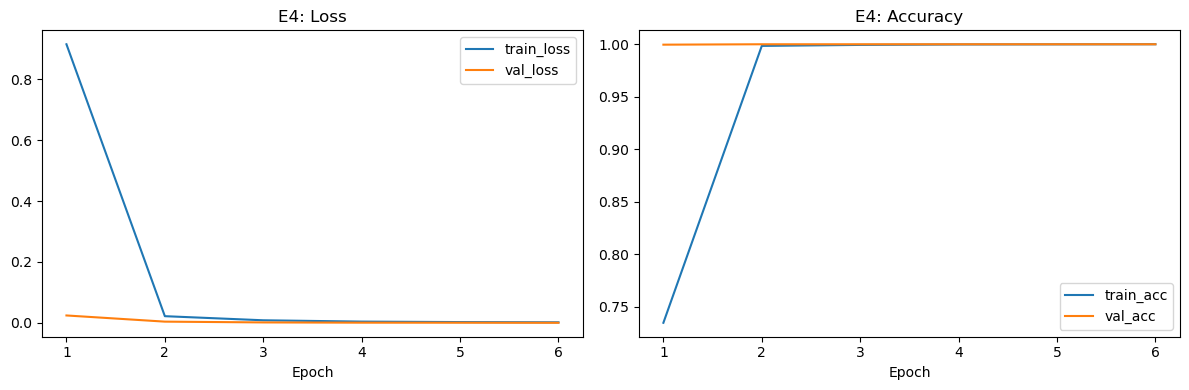

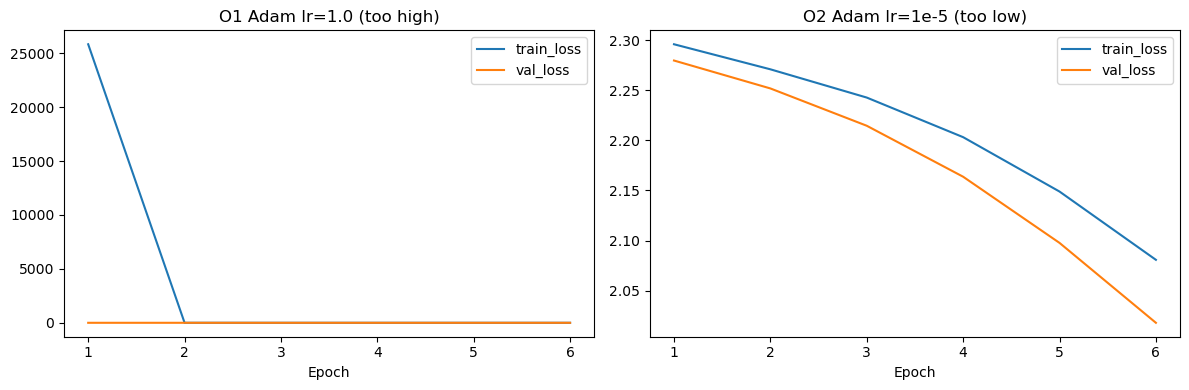

saved: homeworks/HW08-09/artifacts/runs.csv
saved: homeworks/HW08-09/artifacts/figures/curves_best.png
saved: homeworks/HW08-09/artifacts/figures/curves_lr_extremes.png


In [ ]:
# Сохранение runs.csv
fieldnames = [
    'experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr', 'momentum', 'weight_decay',
    'epochs_trained', 'best_val_accuracy', 'best_val_loss'
]
with open(RUNS_PATH, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in results:
        writer.writerow({
            'experiment_id': r.experiment_id,
            'dataset': r.dataset,
            'seed': r.seed,
            'model_summary': r.model_summary,
            'optimizer': r.optimizer,
            'lr': f'{r.lr:.6g}',
            'momentum': f'{r.momentum:.6g}',
            'weight_decay': f'{r.weight_decay:.6g}',
            'epochs_trained': r.epochs_trained,
            'best_val_accuracy': f'{r.best_val_accuracy:.6f}',
            'best_val_loss': f'{r.best_val_loss:.6f}',
        })

# curves_best.png
epochs = np.arange(1, len(E4.history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, E4.history['train_loss'], label='train_loss')
axes[0].plot(epochs, E4.history['val_loss'], label='val_loss')
axes[0].set_title('E4: Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(epochs, E4.history['train_acc'], label='train_acc')
axes[1].plot(epochs, E4.history['val_acc'], label='val_acc')
axes[1].set_title('E4: Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
fig.tight_layout()
fig.savefig(CURVES_BEST_PATH, dpi=150)
plt.show()
plt.close(fig)

# curves_lr_extremes.png
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
e1 = np.arange(1, len(O1.history['train_loss']) + 1)
e2 = np.arange(1, len(O2.history['train_loss']) + 1)
axes[0].plot(e1, O1.history['train_loss'], label='train_loss')
axes[0].plot(e1, O1.history['val_loss'], label='val_loss')
axes[0].set_title('O1 Adam lr=1.0 (too high)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(e2, O2.history['train_loss'], label='train_loss')
axes[1].plot(e2, O2.history['val_loss'], label='val_loss')
axes[1].set_title('O2 Adam lr=1e-5 (too low)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
fig.tight_layout()
fig.savefig(CURVES_LR_EXTREMES_PATH, dpi=150)
plt.show()
plt.close(fig)

print('saved:', RUNS_PATH)
print('saved:', CURVES_BEST_PATH)
print('saved:', CURVES_LR_EXTREMES_PATH)

In [ ]:
# Финальная оценка на test только для лучшей модели (E4)
criterion = nn.CrossEntropyLoss()
best_model = MLP(**best_cfg).to(device)
best_model.load_state_dict(E4.best_state)

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print('Final test_loss:', round(test_loss, 6))
print('Final test_acc:', round(test_acc, 6))

torch.save(E4.best_state, BEST_MODEL_PATH)

best_config = {
    'dataset': DATASET_NAME,
    'seed': SEED,
    'device': str(device),
    'model': best_cfg,
    'optimizer': {'name': 'Adam', 'lr': 1e-3, 'weight_decay': 0.0},
    'early_stopping_patience': 4,
    'epochs_trained': E4.epochs_trained,
    'best_val_accuracy': E4.best_val_accuracy,
    'best_val_loss': E4.best_val_loss,
    'final_test_loss': test_loss,
    'final_test_accuracy': test_acc,
}
with open(BEST_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print('saved:', BEST_MODEL_PATH)
print('saved:', BEST_CONFIG_PATH)

Final test_loss: 0.006112
Final test_acc: 0.998535
saved: homeworks/HW08-09/artifacts/best_model.pt
saved: homeworks/HW08-09/artifacts/best_config.json
